In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
288,7.07,21.0,0
58,7.34,43.0,0
116,7.16,21.0,0
57,7.73,24.0,0
417,6.90,19.0,0


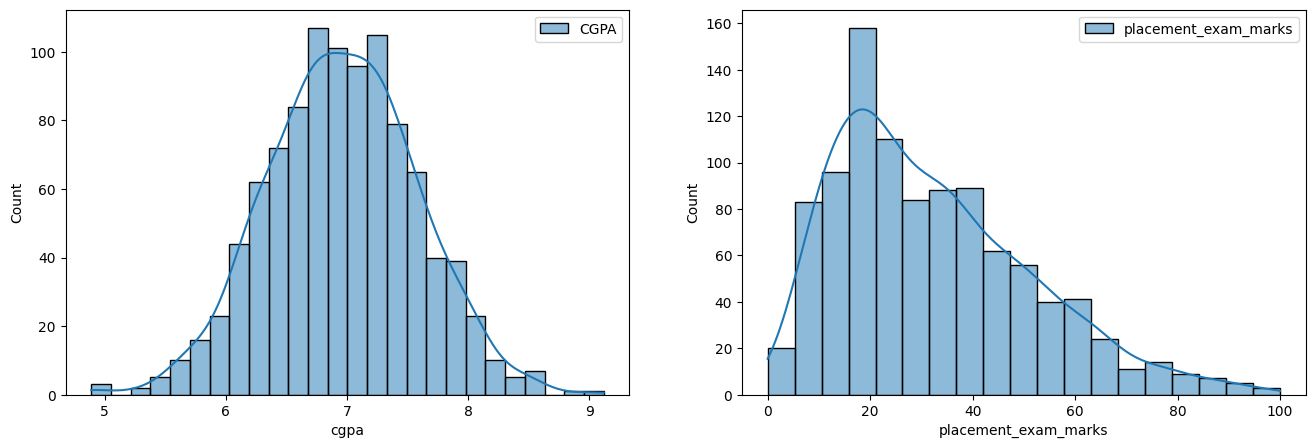

In [3]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df['cgpa'],label='CGPA',kde=True)
plt.legend()
plt.subplot(122)
sns.histplot(df['placement_exam_marks'],kde=True,label='placement_exam_marks')
plt.legend()

In [4]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [5]:
df['cgpa'].skew()

-0.014529938929314918

In [6]:
df['placement_exam_marks'].skew()

0.8356419499466834

<Axes: >

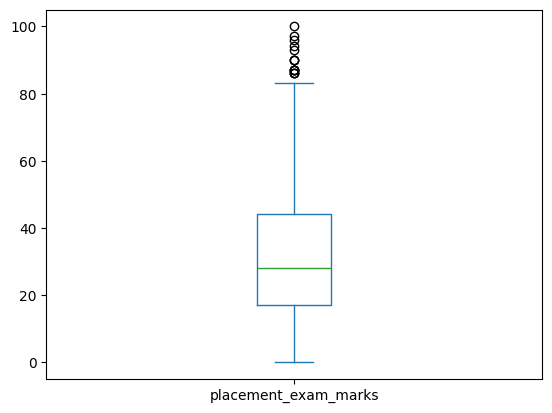

In [7]:
df['placement_exam_marks'].plot.box()

In [8]:
#finding the iqr
percentil25=df['placement_exam_marks'].quantile(0.25)
percentil75=df['placement_exam_marks'].quantile(0.75)

In [9]:
percentil75,percentil25

(44.0, 17.0)

In [10]:
iqr=percentil75-percentil25
iqr

27.0

In [11]:
upper_limit=percentil75+ 1.5 * iqr
lower_limit=percentil25 -1.5 * iqr

In [12]:
print("upper limit :",upper_limit)
print("lower_limit:",lower_limit)

upper limit : 84.5
lower_limit: -23.5


Finding Outliers

In [13]:
df[(df['placement_exam_marks']> upper_limit) | (df['placement_exam_marks']<lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


            Trimming

In [14]:
new_df=df[(df['placement_exam_marks']< upper_limit) & (df['placement_exam_marks']>lower_limit)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [15]:
df.shape,new_df.shape

((1000, 3), (985, 3))

<Axes: ylabel='placement_exam_marks'>

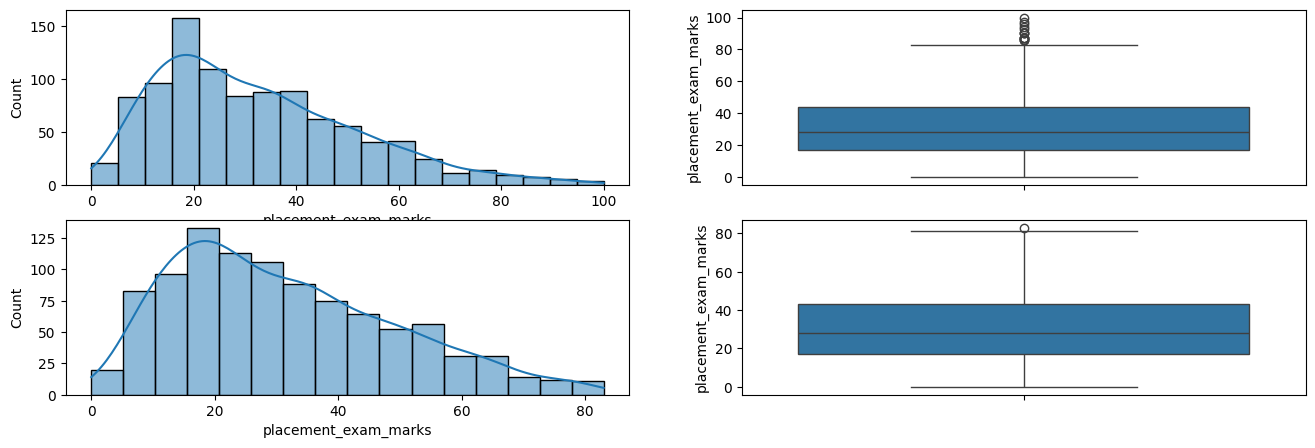

In [16]:
plt.figure(figsize=(16,5))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(223)
sns.histplot(new_df['placement_exam_marks'],kde=True)
plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])

In [17]:
df['placement_exam_marks'].skew(),new_df['placement_exam_marks'].skew()

(0.8356419499466834, 0.6549925627115251)

                    Capping

In [38]:
new_df_cap=df.copy()
new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        df['placement_exam_marks']
    )
)

In [39]:
new_df_cap.shape

(1000, 3)

<Axes: ylabel='placement_exam_marks'>

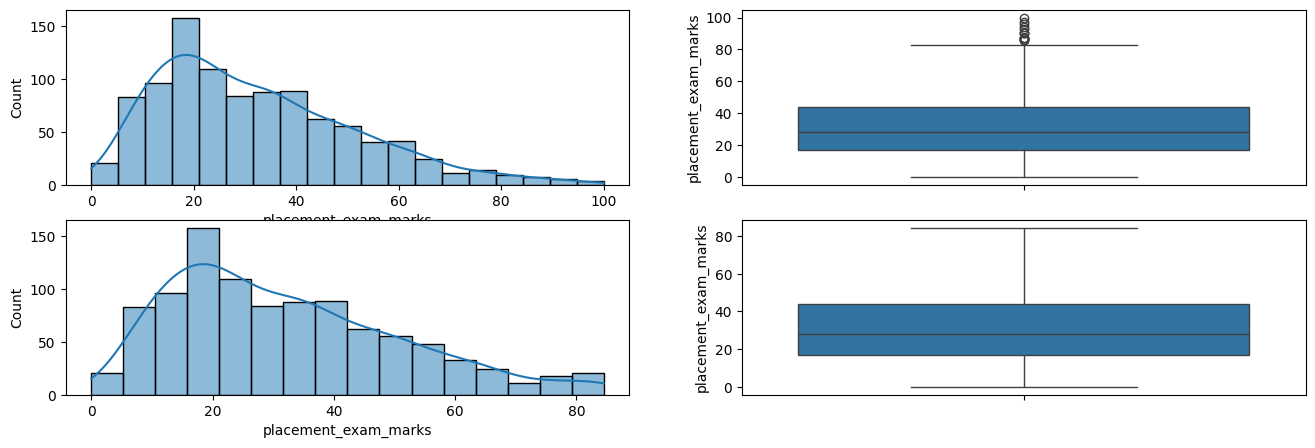

In [40]:
plt.figure(figsize=(16,5))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(223)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)
plt.subplot(224)
sns.boxplot(new_df_cap['placement_exam_marks'])

In [42]:
new_df_cap['placement_exam_marks'].skew()

0.7566838441374795